# Random Forest Model

## Importing all train/test pickle files as well as cleaned data

In [1]:
import pickle as pk

df_cleaned = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\df_cleaned.pkl", 'rb') as file:
    df_cleaned = pk.load(file)

In [2]:
df_cleaned.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,50002,1,3,Phone,1,8,Electronic Payment,Male,3,4,Mobile Phone,3,Single,7,1,15,0,1,0,120.90
2,50003,1,3,Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,1,14,0,1,3,120.28
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,50005,1,0,Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,0,11,1,1,3,129.60


In [3]:
X_train = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\X_train.pkl", 'rb') as file:
    X_train = pk.load(file)

In [4]:
X_train.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
2901,4,1,7,3,5,3,3,0,23,3,...,0,1,0,1,0,0,0,0,0,1
1450,30,2,8,2,4,1,10,0,21,0,...,0,0,1,0,0,0,0,1,1,0
2437,3,1,34,3,3,1,5,0,20,1,...,0,0,0,1,0,0,1,0,1,0
4027,2,3,10,4,4,4,3,0,20,2,...,1,0,0,0,0,0,1,0,1,0
362,0,1,6,3,4,4,2,0,13,1,...,0,1,0,0,0,0,1,0,0,1


In [5]:
X_test = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\X_test.pkl", 'rb') as file:
    X_test = pk.load(file)

In [6]:
X_test.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
1907,0,1,6,3,3,1,2,1,13,6,...,0,0,1,1,0,0,1,0,0,1
1422,18,1,12,2,3,5,5,1,14,1,...,0,0,1,1,0,0,0,0,1,0
3435,29,1,25,4,4,4,5,1,15,7,...,1,0,0,1,0,1,0,0,0,0
5601,30,1,8,3,4,3,3,0,22,1,...,0,1,0,1,0,1,0,0,1,0
2708,6,3,16,2,3,3,2,0,14,0,...,0,0,1,1,0,1,0,0,0,1


In [7]:
y_train = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\y_train.pkl", 'rb') as file:
    y_train = pk.load(file)

In [8]:
y_train.head()

2901    0
1450    0
2437    0
4027    0
362     0
Name: Churn, dtype: int64

In [9]:
y_test = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\y_test.pkl", 'rb') as file:
    y_test = pk.load(file)

In [10]:
y_test.head()

1907    1
1422    0
3435    0
5601    0
2708    0
Name: Churn, dtype: int64

## Building the Model

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rs=1234

In [12]:
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': np.arange(50, 200, 25),  # number of trees
    'max_depth': np.arange(2, 15, 1),        # tree depth
    'class_weight': [None, 'balanced']       # handle imbalance
}

In [13]:
# Initialize Random Forest (base model)
rf = RandomForestClassifier(
    random_state=rs,
    max_samples=None   
)

In [14]:
# Randomized Search for best hyperparameters
rf_tuner = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=40,
    scoring='balanced_accuracy',
    cv=5,
    verbose=1,
    random_state=rs
)

# Fit tuner
rf_tuner.fit(X_train, y_train)

# Show best parameters
print("Best Parameters:", rf_tuner.best_params_)

# Retrieve the tuned model
rf_model = rf_tuner.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'n_estimators': np.int64(175), 'max_depth': np.int64(14), 'class_weight': None}


In [15]:
# Fit the final model using the best parameters
rf_model.fit(X_train, y_train)


,n_estimators,np.int64(175)
,criterion,'gini'
,max_depth,np.int64(14)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# Predict on training and test sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [17]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Full classification report on test set
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred))


Train Accuracy: 0.9995548631204095
Test Accuracy: 0.9572953736654805

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       935
           1       0.96      0.78      0.86       189

    accuracy                           0.96      1124
   macro avg       0.96      0.89      0.92      1124
weighted avg       0.96      0.96      0.96      1124



In [18]:
# Feature Importance DataFrame

# Get feature importances from the model
importances = rf_model.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Show top 10 most important features
print(feat_imp.head(10))


                        Feature  Importance
0                        Tenure    0.225073
12               CashbackAmount    0.095657
2               WarehouseToHome    0.073872
7                      Complain    0.065475
6               NumberOfAddress    0.062594
11            DaySinceLastOrder    0.060749
8   OrderAmountHikeFromlastYear    0.057949
5             SatisfactionScore    0.048672
4      NumberOfDeviceRegistered    0.036873
10                   OrderCount    0.030889


## Visuals

### Confustion Matrix

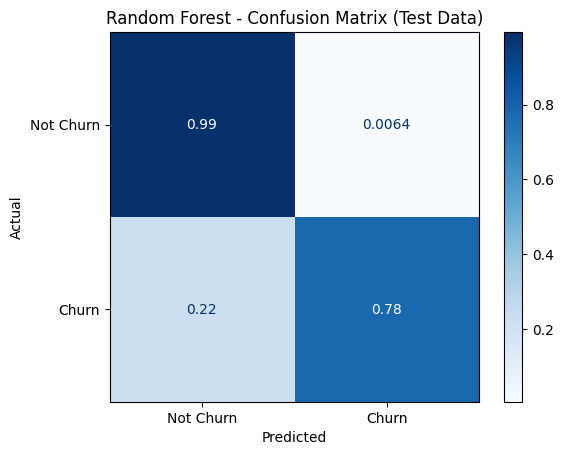

In [20]:
# Compute confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred, normalize='true')

# Create and plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Feature Importance Bar Chart

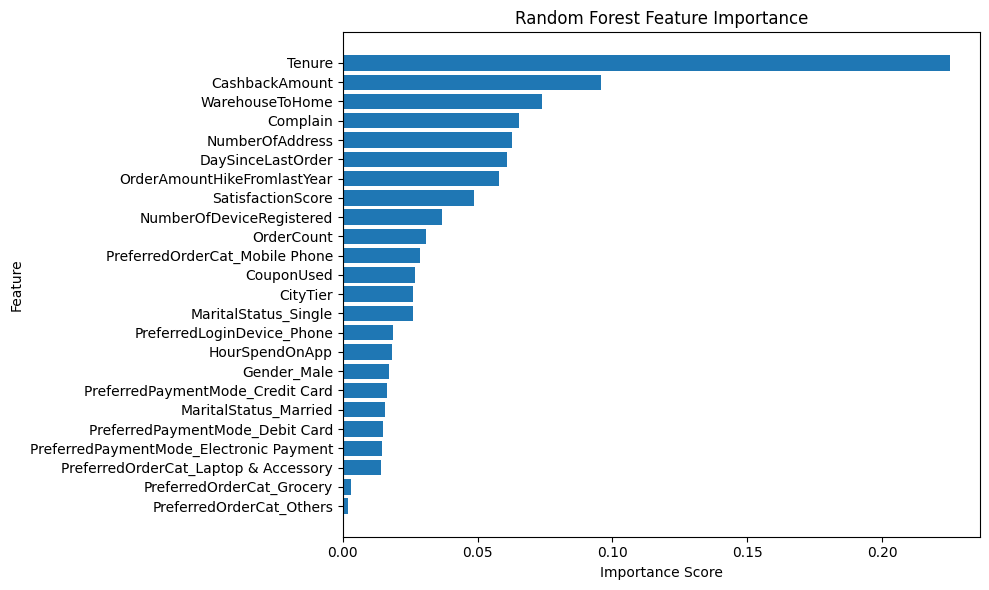

In [27]:
# Bar Chart of Feature Importance
top_features = feat_imp.sort_values(by='Importance', ascending=False)  # ← ONLY CHANGE

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()   # highest importance at top

plt.title("Random Forest Feature Importance") 
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Analysis

### Model Performance

Accuracy: 0.957

Class = 0 (Non-Churn)
- Recall = 0.99
- The model almost never misses customers who stay.

Class = 1 (Churn)
- Recall = 0.78
- The model correctly identifies most churners.

### Interpretation

Overall Model Performance
- The Random Forest performs very well overall, reaching 96% accuracy.
- It correctly classifies non-churn customers almost perfectly.
- Most importantly, its ability to identify churners improved significantly, meaning it now captures the majority of customers who actually leave.
- This makes the model more useful for real decision-making, because the business can intervene before customers churn.
- Train Accuracy = 99.96%, Test Accuracy = 95.73%; the slight difference indicates a small degree of overfitting, but the model still generalizes well to unseen data.

### Feature Importance

Top Predictors of Churn:
- Tenure is the strongest predictor; shorter-tenured customers are more likely to churn.
- CashbackAmount and WarehouseToHome distance also strongly influence churn, indicating customers respond to incentives and delivery convenience.
- Complain, NumberOfAddress, and DaySinceLastOrder capture behavior patterns linked to dissatisfaction or inactivity.

Other Influential Predictors:
- Features like OrderAmountHikeFromlastYear, SatisfactionScore, and NumberOfDeviceRegistered have smaller but noticeable effects on churn.

Overall Interpretation:
- Churn is driven by a combination of loyalty (Tenure), customer behavior (Complaints, Order frequency), and value/convenience factors (Cashback, Delivery distance).
- These features collectively help the model identify customers at higher risk of leaving versus those likely to stay.

In [22]:
import pickle

# Save the model
with open("4_Random_Forest.pkl", "wb") as file:
    pickle.dump('4_Random_Forest', file)